In [2]:
import os, sys, glob, shutil, re, pickle
import subprocess
import seaborn as sns

import mdtraj as md
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import math
from IPython.display import Image, display
%matplotlib inline
nmer = 5
mpl.rcParams.update({'font.size': 16})

## Important Function

In [3]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)

In [4]:
# Define the directory path
directory = "log_data/"

remove_and_clean = True

# Check if the directory exists
if os.path.exists(directory):
    if remove_and_clean:
        # Remove all contents of the directory
        shutil.rmtree(directory)
        # Recreate the empty directory
        os.makedirs(directory)
        print(f"All contents in '{directory}' have been cleared.")
    else:
        print(f"Directory '{directory}' already exists. No action taken.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

Directory 'log_data/' did not exist, so it has been created.


## Extract Log information

In [5]:
state_num = 16
HREX_dir = '../traj_remd'
run_num = 1 # How many run

HREX_list = [f"REMD_200ns_{i}" for i in range(1, run_num + 1)]
HREX_list



['REMD_200ns_1']

In [6]:
import os

pattern = 'Repl ex'
VERBOSE = False

n_pairs = 15  # for 16 replicas → 15 exchange pairs
attempt_counts = [0] * n_pairs
total_lines = 0

for HREX in HREX_list:
    HREX_path = os.path.join(HREX_dir, HREX)
    logfile = os.path.join(HREX_path, 'state_0/HREMD.part0001.log')

    try:
        with open(logfile, 'r') as file:
            for line in file:
                if pattern in line:
                    total_lines += 1
                    parts = line.strip().split()

                    if VERBOSE:
                        print(f"parts: {parts}")

                    for i, val in enumerate(parts):
                        if val == 'x' and i > 2:  # skip 'Repl', 'ex', '0'
                            pair_index = i - 3
                            if 0 <= pair_index < n_pairs:
                                attempt_counts[pair_index] += 1

    except Exception as e:
        print(f"[ERROR] Failed to process {logfile}: {e}")
        continue

    #break  # Remove to process all entries

# Compute exchange probabilities
exchange_probs = [attempts / (total_lines / 2 ) for attempts in attempt_counts]

# Display results
for i, prob in enumerate(exchange_probs):
    print(f"Replica pair {i}-{i+1}: {prob:.3f} exchange probability ({attempt_counts[i]}/{total_lines / 2 })")


Replica pair 0-1: 0.219 exchange probability (21867/99999.5)
Replica pair 1-2: 0.207 exchange probability (20671/99999.5)
Replica pair 2-3: 0.157 exchange probability (15694/99999.5)
Replica pair 3-4: 0.198 exchange probability (19778/99999.5)
Replica pair 4-5: 0.156 exchange probability (15578/99999.5)
Replica pair 5-6: 0.177 exchange probability (17709/99999.5)
Replica pair 6-7: 0.153 exchange probability (15306/99999.5)
Replica pair 7-8: 0.158 exchange probability (15755/99999.5)
Replica pair 8-9: 0.140 exchange probability (13982/99999.5)
Replica pair 9-10: 0.139 exchange probability (13858/99999.5)
Replica pair 10-11: 0.125 exchange probability (12514/99999.5)
Replica pair 11-12: 0.120 exchange probability (11961/99999.5)
Replica pair 12-13: 0.109 exchange probability (10890/99999.5)
Replica pair 13-14: 0.098 exchange probability (9774/99999.5)
Replica pair 14-15: 0.082 exchange probability (8227/99999.5)


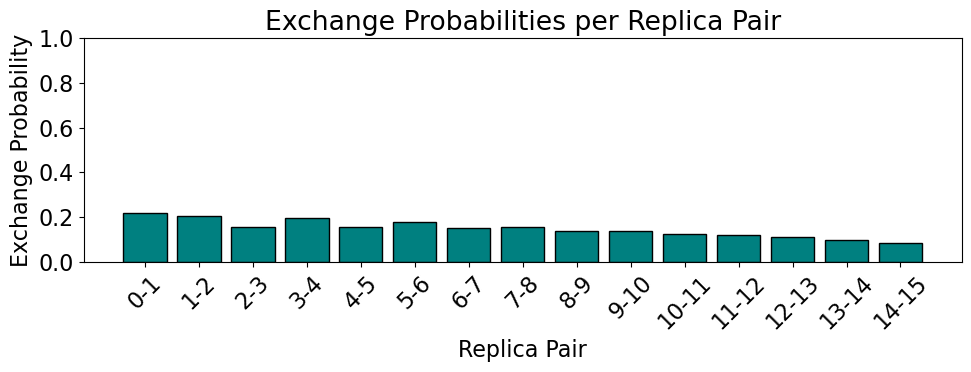

In [7]:
import matplotlib.pyplot as plt

# Plot exchange probabilities as a histogram
plt.figure(figsize=(10, 4))
x = list(range(len(exchange_probs)))
plt.bar(x, exchange_probs, color='teal', edgecolor='black')

plt.xticks(x, [f'{i}-{i+1}' for i in x], rotation=45)
plt.xlabel('Replica Pair')
plt.ylabel('Exchange Probability')
plt.title('Exchange Probabilities per Replica Pair')
plt.ylim(0, 1.0)

plt.tight_layout()
plt.show()
